<a href="https://colab.research.google.com/github/Exton-wz/PCVK-Ganjil-2026/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUGAS PRAKTIKUM PENERAPAN

NB : Praktikum week 2 ada di ipynb week 1

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


=== HASIL ANALISA KANAL WARNA DOMINAN ===
Rata-rata intensitas Merah (R) : 178.56
Rata-rata intensitas Hijau (G) : 188.67
Rata-rata intensitas Biru  (B) : 212.25

-> Kesimpulan: Kanal BIRU paling dominan.


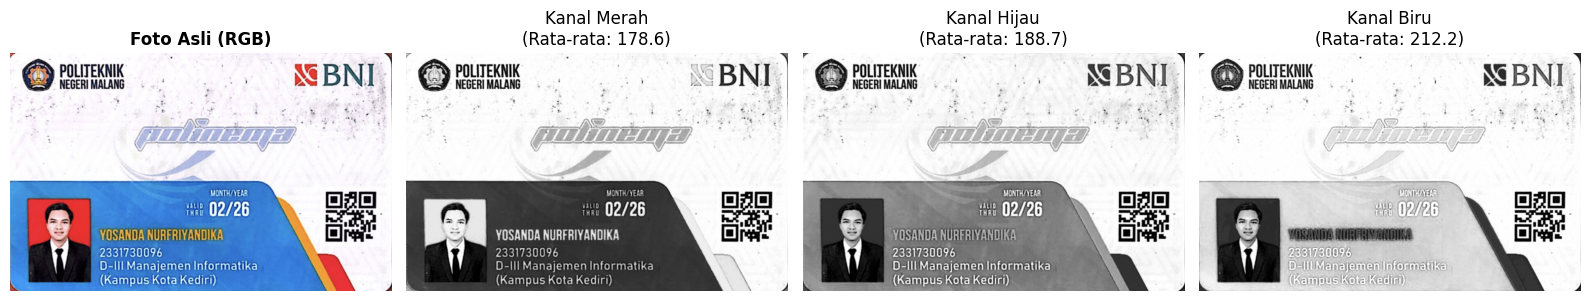

In [2]:
import numpy as np
from skimage import io
import matplotlib.pyplot as plt
path_gambar = '/content/drive/MyDrive/PCVK 2026/IMG_9679.png'

img_rgb = io.imread(path_gambar)

kanal_merah = img_rgb[:, :, 0]
kanal_hijau = img_rgb[:, :, 1]
kanal_biru  = img_rgb[:, :, 2]

rata_merah = np.mean(kanal_merah)
rata_hijau = np.mean(kanal_hijau)
rata_biru  = np.mean(kanal_biru)

print("=== HASIL ANALISA KANAL WARNA DOMINAN ===")
print(f"Rata-rata intensitas Merah (R) : {rata_merah:.2f}")
print(f"Rata-rata intensitas Hijau (G) : {rata_hijau:.2f}")
print(f"Rata-rata intensitas Biru  (B) : {rata_biru:.2f}")

tertinggi = max(rata_merah, rata_hijau, rata_biru)
if tertinggi == rata_merah:
    print("\n-> Kesimpulan: Kanal MERAH paling dominan.")
elif tertinggi == rata_hijau:
    print("\n-> Kesimpulan: Kanal HIJAU paling dominan.")
else:
    print("\n-> Kesimpulan: Kanal BIRU paling dominan.")

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Foto Asli (RGB)', fontweight='bold')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(kanal_merah, cmap='gray')
plt.title(f'Kanal Merah\n(Rata-rata: {rata_merah:.1f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(kanal_hijau, cmap='gray')
plt.title(f'Kanal Hijau\n(Rata-rata: {rata_hijau:.1f})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(kanal_biru, cmap='gray')
plt.title(f'Kanal Biru\n(Rata-rata: {rata_biru:.1f})')
plt.axis('off')

plt.tight_layout()
plt.show()

TUGAS PRAKTIKUM APLIKASI STUDI KASUS 1

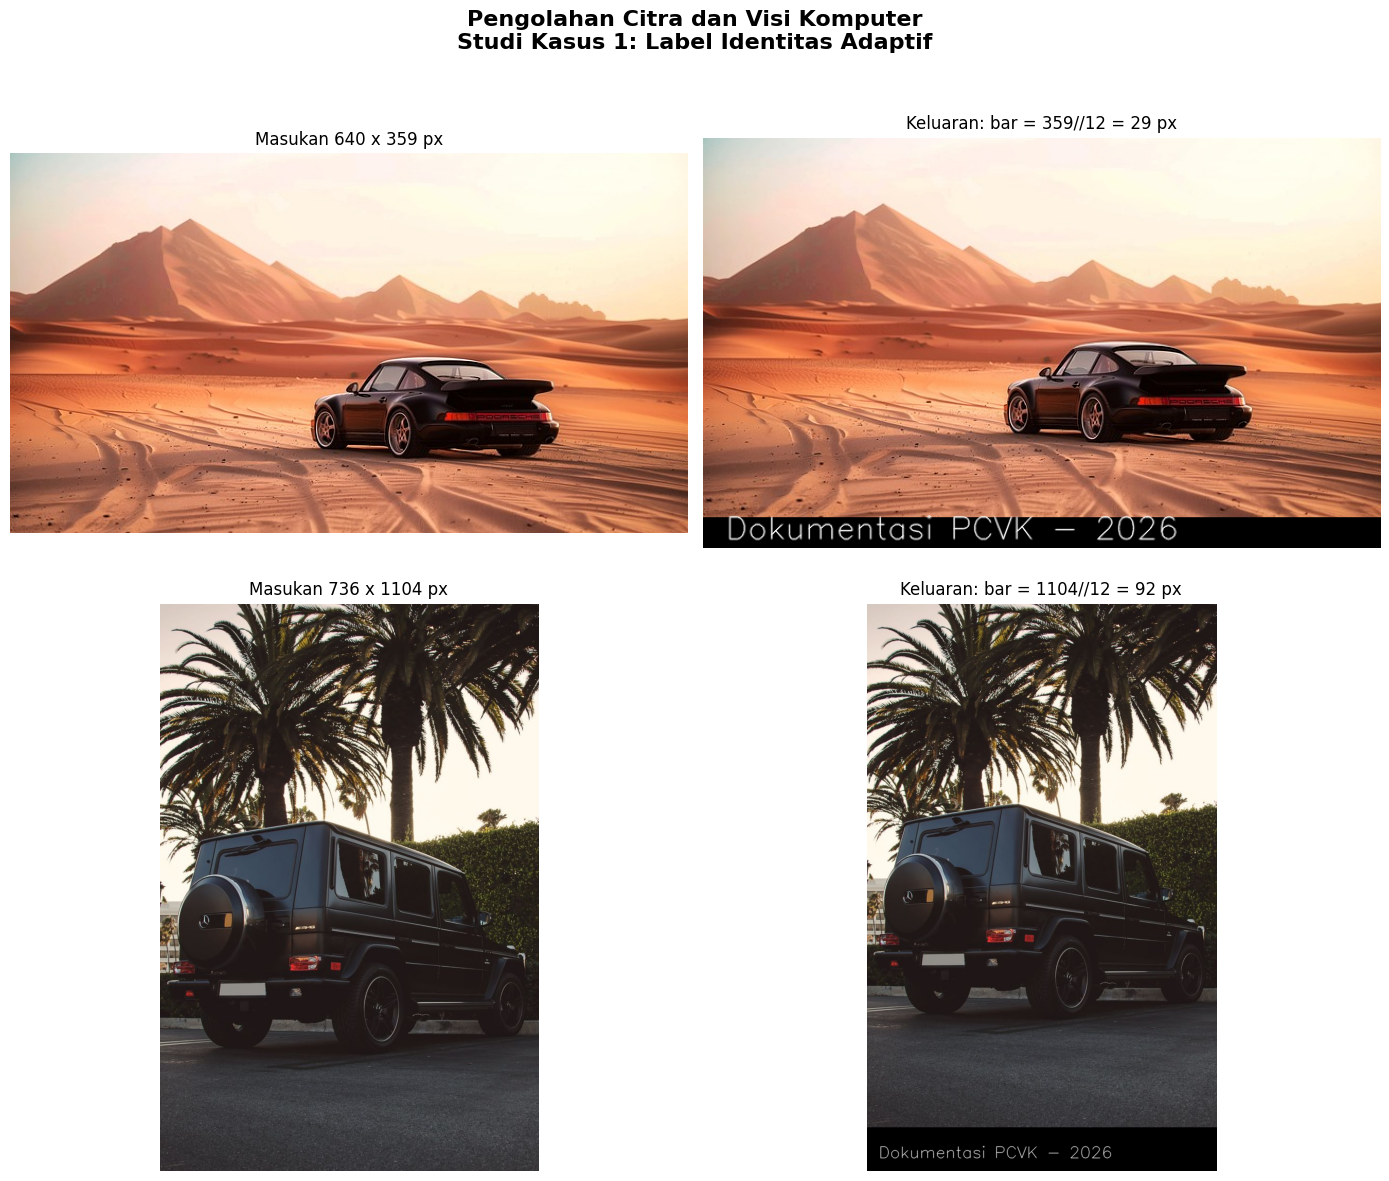

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import io


def tambah_bar_dokumentasi(img):
    h, w = img.shape[:2]
    bar_h = h // 12

    canvas = np.zeros((h + bar_h, w, 3), dtype=np.uint8)
    canvas[:h, :] = img

    teks = "Dokumentasi PCVK - 2026"
    font = cv.FONT_HERSHEY_SIMPLEX

    # Proporsi dihitung dari lebar gambar (w)
    font_scale = w / 650.0
    thickness = max(1, w // 400)

    pos_x = w // 30
    pos_y = h + int(bar_h * 0.7)

    cv.putText(canvas, teks, (pos_x, pos_y), font, font_scale, (255, 255, 255), thickness, cv.LINE_AA)

    return canvas, w, h, bar_h

path_landscape = '/content/drive/MyDrive/PCVK 2026/porsche_landscape.jpg'
path_portrait = '/content/drive/MyDrive/PCVK 2026/Gwagon_protrait.jpg'


img_land = io.imread(path_landscape)
if img_land.shape[-1] == 4:
    img_land = img_land[:, :, :3]

img_port = io.imread(path_portrait)
if img_port.shape[-1] == 4:
    img_port = img_port[:, :, :3]


hasil_land, w_L, h_L, bar_L = tambah_bar_dokumentasi(img_land)
hasil_port, w_P, h_P, bar_P = tambah_bar_dokumentasi(img_port)


# Membuat figure dengan 2 baris dan 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Pengolahan Citra dan Visi Komputer\nStudi Kasus 1: Label Identitas Adaptif', fontsize=16, fontweight='bold')

# --- Baris Atas: Gambar Landscape ---
axes[0, 0].imshow(img_land)
axes[0, 0].set_title(f'Masukan {w_L} x {h_L} px')
axes[0, 0].axis('off')

axes[0, 1].imshow(hasil_land)
axes[0, 1].set_title(f'Keluaran: bar = {h_L}//12 = {bar_L} px')
axes[0, 1].axis('off')

# --- Baris Bawah: Gambar Portrait ---
axes[1, 0].imshow(img_port)
axes[1, 0].set_title(f'Masukan {w_P} x {h_P} px')
axes[1, 0].axis('off')

axes[1, 1].imshow(hasil_port)
axes[1, 1].set_title(f'Keluaran: bar = {h_P}//12 = {bar_P} px')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

TUGAS PRAKTIKUM APLIKASI STUDI KASUS 2

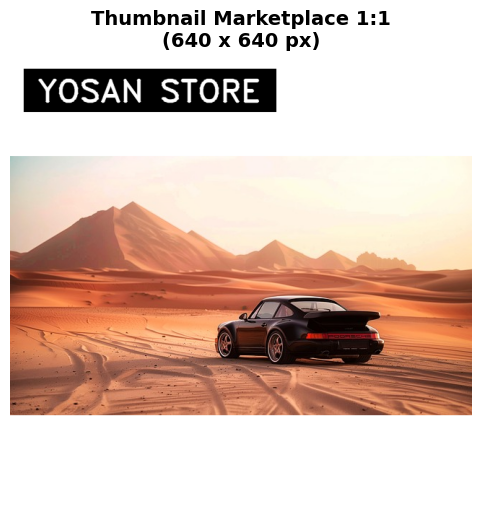

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

def buat_thumbnail_persegi(img, nama_toko="YOSAN STORE"):
    h, w = img.shape[:2]

    # 1. Sisi kanvas diambil dari nilai maksimum (sisi terpanjang) agar menjadi persegi (1:1)
    side = max(h, w)

    # 2. Buat kanvas kosong berwarna putih (255) dengan dimensi (side x side)
    canvas = np.full((side, side, 3), 255, dtype=np.uint8)

    # 3. Hitung titik tengah (centering)
    y_offset = (side - h) // 2
    x_offset = (side - w) // 2

    # 4. Tempelkan gambar asli tepat di tengah kanvas menggunakan Slicing
    canvas[y_offset : y_offset + h, x_offset : x_offset + w] = img

    # 5. Desain Badge Logo Toko di pojok atas
    font = cv.FONT_HERSHEY_DUPLEX
    font_scale = side / 450.0
    thickness = max(1, int(font_scale * 2))

    (text_width, text_height), baseline = cv.getTextSize(nama_toko, font, font_scale, thickness)

    padding = int(side * 0.03)
    box_x1 = padding
    box_y1 = padding
    box_x2 = int(padding + text_width + (padding * 2))
    box_y2 = int(padding + text_height + (padding * 1.5))

    # Gambar kotak latar belakang badge
    cv.rectangle(canvas, (box_x1, box_y1), (box_x2, box_y2), (0, 0, 0), -1)

    # Gambar teks putih di dalam badge
    text_x = box_x1 + padding
    text_y = box_y1 + int(text_height + padding * 0.75)
    cv.putText(canvas, nama_toko, (text_x, text_y), font, font_scale, (255, 255, 255), thickness, cv.LINE_AA)

    return canvas, side

# =========================================================================
# EKSEKUSI & PLOT KHUSUS THUMBNAIL KOTAK 1:1
# =========================================================================
path_landscape = '/content/drive/MyDrive/PCVK 2026/porsche_landscape.jpg'
img_l = io.imread(path_landscape)

if img_l.shape[-1] == 4:
    img_l = img_l[:, :, :3]

thumb_l, side_l = buat_thumbnail_persegi(img_l, "YOSAN STORE")

# Buat figur murni persegi (6x6 inci) agar rasio visualnya benar-benar 1:1
plt.figure(figsize=(6, 6))
plt.imshow(thumb_l)
plt.title(f'Thumbnail Marketplace 1:1\n({side_l} x {side_l} px)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()